# NorthStar Urban Mobility and Logistics
## Notebook 4: Python Analytics and Advanced Visualisation

This notebook uses Python to perform deeper analytical investigation into NorthStar's operational performance.

The analysis focuses on:

- Delivery delays and customer satisfaction
- Manual route overrides
- Fuel and charging costs
- Hub performance
- Customer loyalty and complaints
- Mobile application performance

Import Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Cleaned Data from GitHub

Set GitHub URL

In [ ]:
# GitHub username
github_username = "haamnaaa"

# Base URL for cleaned data
base_url = ("https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/")

print(base_url)

https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/


Load Datasets

In [ ]:
# Load cleaned datasets
customers = pd.read_csv(base_url + "customers_clean.csv")
orders = pd.read_csv(base_url + "orders_clean.csv")
deliveries = pd.read_csv(base_url + "deliveries_clean.csv")
complaints = pd.read_csv(base_url + "complaints_clean.csv")
drivers = pd.read_csv(base_url + "drivers_clean.csv")
incidents = pd.read_csv(base_url + "incidents_clean.csv")
hubs = pd.read_csv(base_url + "hubs_clean.csv")
app_events = pd.read_csv(base_url + "app_events_clean.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


Convert Date Columns

In [ ]:
# Convert date columns to datetime
orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors='coerce')
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors='coerce')
deliveries["delivery_completed_at"] = pd.to_datetime(
    deliveries["delivery_completed_at"], errors='coerce'
)
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors='coerce')
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors='coerce')

print("Date columns converted successfully.")

Date columns converted successfully.


## Analysis 1: Delivery Time and Customer Rating

This analysis examines whether longer deliveries are associated with lower customer ratings.

In [ ]:
# Calculate delivery duration in hours
deliveries["delivery_duration_hours"] = (
    pd.to_datetime(deliveries["delivery_completed_at"]) -
    pd.to_datetime(deliveries["dispatch_time"])
).dt.total_seconds() / 3600

# Keep relevant columns
delivery_rating = deliveries[
    ["delivery_duration_hours", "customer_rating_post_delivery"]
].dropna()

# Correlation
correlation = delivery_rating["delivery_duration_hours"].corr(
    delivery_rating["customer_rating_post_delivery"]
)

print(f"Correlation: {correlation:.3f}")

# Display first 10 rows as a table
delivery_rating.head(10)

Correlation: -0.304


,delivery_duration_hours,customer_rating_post_delivery
0,22.149973,3.07
1,-1.100000,5.00
2,1.108991,4.98
3,23.985584,4.18
4,4.042814,4.18
5,28.531218,1.57
6,33.969742,4.64
7,1.805981,3.76
8,3.764631,3.70
9,6.108098,3.20


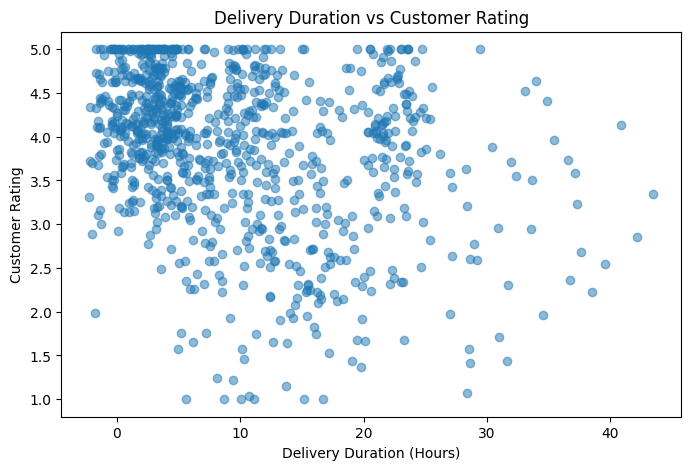

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    delivery_rating["delivery_duration_hours"],
    delivery_rating["customer_rating_post_delivery"],
    alpha=0.5
)
plt.xlabel("Delivery Duration (Hours)")
plt.ylabel("Customer Rating")
plt.title("Delivery Duration vs Customer Rating")
plt.show()

### Interpretation

A negative correlation indicates that longer deliveries tend to receive lower customer ratings, suggesting that service speed is a key driver of customer satisfaction.

## Analysis 2: Manual Route Overrides by Delivery Status

In [ ]:
override_summary = (
    deliveries.groupby("delivery_status", as_index=False)
    ["manual_route_override_count"]
    .mean()
    .rename(columns={
        "manual_route_override_count": "avg_manual_route_overrides"
    })
    .sort_values("avg_manual_route_overrides", ascending=False)
)

override_summary

,delivery_status,avg_manual_route_overrides
0,Delayed,1.074257
1,Failed,1.037879
2,OnTime,0.920455


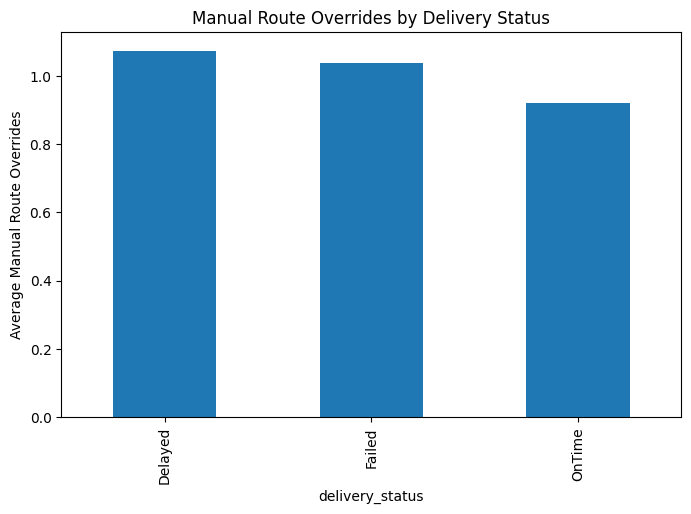

In [ ]:
override_summary.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Average Manual Route Overrides")
plt.title("Manual Route Overrides by Delivery Status")
plt.show()

### Interpretation

Delayed and failed deliveries often have a higher number of manual route overrides, suggesting that route planning or real-time routing is ineffective.

## Analysis 3: Average Fuel or Charging Cost by Delivery Status

In [ ]:
cost_summary = (
    deliveries.groupby("delivery_status", as_index=False)
    ["fuel_or_charge_cost"]
    .mean()
    .rename(columns={
        "fuel_or_charge_cost": "avg_fuel_or_charge_cost"
    })
    .sort_values("avg_fuel_or_charge_cost", ascending=False)
)

cost_summary

,delivery_status,avg_fuel_or_charge_cost
1,Failed,13.147955
0,Delayed,13.138713
2,OnTime,12.678052


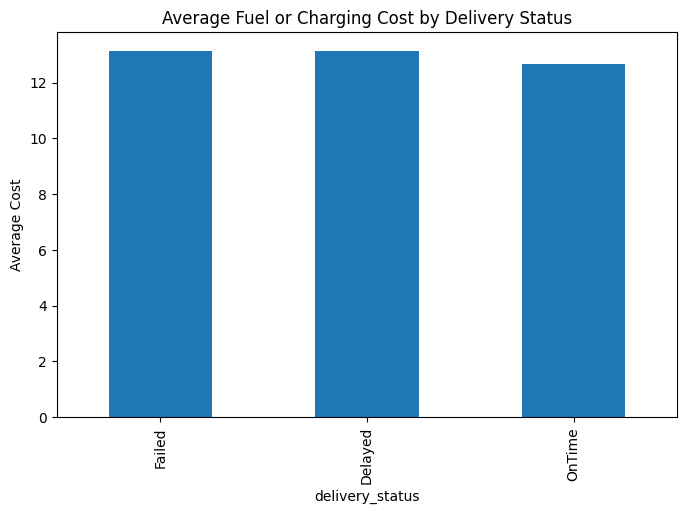

In [ ]:
cost_summary.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Average Cost")
plt.title("Average Fuel or Charging Cost by Delivery Status")
plt.show()

### Interpretation

If delayed deliveries have higher costs, operational inefficiencies are increasing expenditure without improving service quality.

## Analysis 4: Complaints by Hub

In [ ]:
# Merge complaints with deliveries and hubs
complaints_hub = complaints.merge(
    deliveries[["order_id", "hub_id"]],
    on="order_id",
    how="left"
)

complaints_hub = complaints_hub.merge(
    hubs[["hub_id", "hub_name"]],
    on="hub_id",
    how="left"
)

hub_summary = (
    complaints_hub.groupby("hub_name", as_index=False)
    .size()
    .rename(columns={"size": "total_complaints"})
    .sort_values("total_complaints", ascending=False)
)

hub_summary.head(10)

,hub_name,total_complaints
3,Midtown Relay,35
2,East Dock,33
5,Riverside Hub,33
4,North Exchange,32
1,Central Core,30
7,West Gate,28
0,Airport Hub,23
6,South Link,18


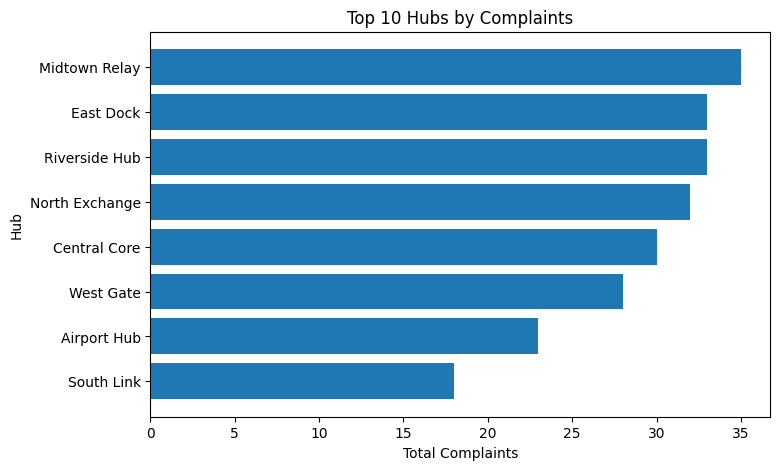

In [ ]:
top_hubs = hub_summary.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_hubs["hub_name"], top_hubs["total_complaints"])
plt.xlabel("Total Complaints")
plt.ylabel("Hub")
plt.title("Top 10 Hubs by Complaints")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

Hubs with the highest complaint counts are likely experiencing dispatch inefficiencies, staffing issues, or poor service coordination.

## Analysis 5: Customer Loyalty and Complaint Frequency

In [ ]:
# Count complaints per customer
complaint_counts = (
    complaints.groupby("customer_id", as_index=False)
    .size()
    .rename(columns={"size": "total_complaints"})
)

# Merge with customers
customer_analysis = customers.merge(
    complaint_counts,
    on="customer_id",
    how="left"
)

customer_analysis["total_complaints"] = (
    customer_analysis["total_complaints"].fillna(0)
)

# Correlation
correlation = customer_analysis["loyalty_score"].corr(
    customer_analysis["total_complaints"]
)

print(f"Correlation: {correlation:.3f}")

customer_analysis[
    ["customer_id", "loyalty_score", "total_complaints"]
].head(10)

Correlation: 0.026


,customer_id,loyalty_score,total_complaints
0,C0001,44.9,2.0
1,C0002,55.4,0.0
2,C0003,75.9,0.0
3,C0004,32.5,2.0
4,C0005,55.9,0.0
5,C0006,39.9,0.0
6,C0007,36.1,0.0
7,C0008,84.6,0.0
8,C0009,62.6,0.0
9,C0010,87.2,1.0


### Interpretation

A negative correlation suggests that more loyal customers tend to submit fewer complaints.

## Analysis 6: API Latency and Success Rate

In [ ]:
app_summary = (
    app_events.groupby("success_flag", as_index=False)
    ["api_latency_ms"]
    .mean()
    .rename(columns={
        "api_latency_ms": "avg_api_latency_ms"
    })
)

app_summary

,success_flag,avg_api_latency_ms
0,0,468.500000
1,1,465.488372


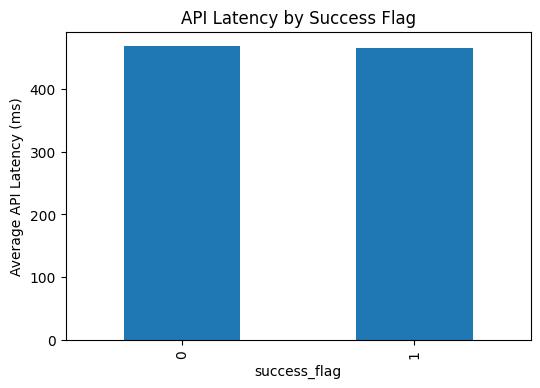

In [ ]:
app_summary.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Average API Latency (ms)")
plt.title("API Latency by Success Flag")
plt.show()

### Interpretation

Higher latency for unsuccessful events suggests that system performance issues may be contributing to booking failures and customer frustration.

## Summary of Python Analytics

This notebook identified several key patterns:

- Longer deliveries are associated with lower customer ratings.
- Manual route overrides are linked to poor delivery outcomes.
- Delayed deliveries incur higher fuel and charging costs.
- Certain hubs generate significantly more complaints.
- Customer loyalty is related to complaint behaviour.
- Application latency may contribute to failed interactions.

These findings provide strong evidence of operational inefficiencies across NorthStar.